Equation for 1 order: 
0.333333333333333*L*q*x/(A*E)
Equation for 2 order: 
0.846153846153846*L*q*x/(A*E) - 0.461538461538462*q*x**2/(A*E)
Equation for 3 order: 
0.968253968253968*L*q*x/(A*E) - 0.793650793650794*q*x**2/(A*E) + 0.211640211640212*q*x**3/(A*E*L)
Equation for 4 order: 
0.993769470404984*L*q*x/(A*E) - 0.934579439252336*q*x**2/(A*E) + 0.43613707165109*q*x**3/(A*E*L) - 0.109034267912773*q*x**4/(A*E*L**2)
Equation for 5 order: 
0.998811645870469*L*q*x/(A*E) - 0.981580510992276*q*x**2/(A*E) + 0.571202218261042*q*x**3/(A*E*L) - 0.262032085561497*q*x**4/(A*E*L**2) + 0.0598930481283422*q*x**5/(A*E*L**3)
Equation for 6 order: 
0.999777505840472*L*q*x/(A*E) - 0.995216375570141*q*x**2/(A*E) + 0.632328401379464*q*x**3/(A*E*L) - 0.380798754032707*q*x**4/(A*E*L**2) + 0.164467682723329*q*x**5/(A*E*L**3) - 0.0342641005673601*q*x**6/(A*E*L**4)


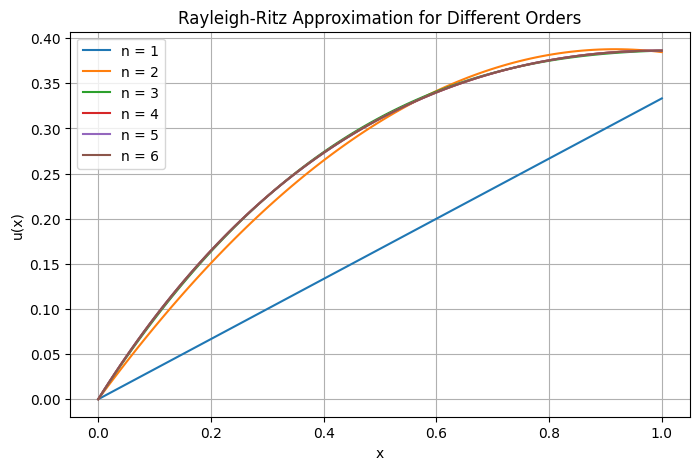

In [ ]:
# Rayleigh-Ritz for a Bar Element
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def rayleigh_ritz(n):
    x, A, E, q, L = sp.symbols('x A E q L')

    # Functions
    E_x = E
    q_x = q
    A_x = A * (1 + x/L)

    # Generating the Polynomial
    coefficients = [sp.Symbol(f'a{i+1}') for i in range(n)]
    u_x = sum(coefficients[i] * x**(i+1) for i in range(len(coefficients)))

    # Finding Strain
    strain = sp.diff(u_x, x)

    # Finding Total Energy
    pie = 0.5 * sp.integrate(A_x * E_x * strain**2, (x, 0, L)) - sp.integrate(q_x * u_x, (x, 0, L))

    # Differentiating with respect to each coefficient
    equations = [sp.diff(pie, coeff) for coeff in coefficients]

    # Solving the system of equations for coefficients
    solutions = sp.solve(equations, coefficients)

    # Final Equation
    u_x_final = u_x.subs(solutions)
    print(f"Equation for {n} order: ")
    print(u_x_final)

    # Plotting the curve
    u_x_func = sp.lambdify(x, u_x_final.subs({A: 1, q: 1, E: 1, L: 1}), 'numpy')
    x_val = np.linspace(0, 1, 100)
    u_x_plot = u_x_func(x_val)
    plt.plot(x_val, u_x_plot, label = f"n = {n}")

# Run the function for different polynomial orders
orders = [1, 2, 3, 4, 5, 6]
plt.figure(figsize=(8, 5))

for order in orders:
    rayleigh_ritz(order)

# Customize the plot
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Rayleigh-Ritz Approximation for Different Orders")
plt.legend()
plt.grid()
plt.show()

Equation for 2 order: 
0.0833333333333333*L**2*q*x**2/(E*I)
Equation for 3 order: 
0.208333333333333*L**2*q*x**2/(E*I) - 0.0833333333333333*L*q*x**3/(E*I)
Equation for 4 order: 
0.25*L**2*q*x**2/(E*I) - 0.166666666666667*L*q*x**3/(E*I) + 0.0416666666666667*q*x**4/(E*I)
Equation for 5 order: 
0.25*L**2*q*x**2/(E*I) - 0.166666666666667*L*q*x**3/(E*I) + 0.0416666666666667*q*x**4/(E*I)
Equation for 6 order: 
0.25*L**2*q*x**2/(E*I) - 0.166666666666667*L*q*x**3/(E*I) + 0.0416666666666667*q*x**4/(E*I)


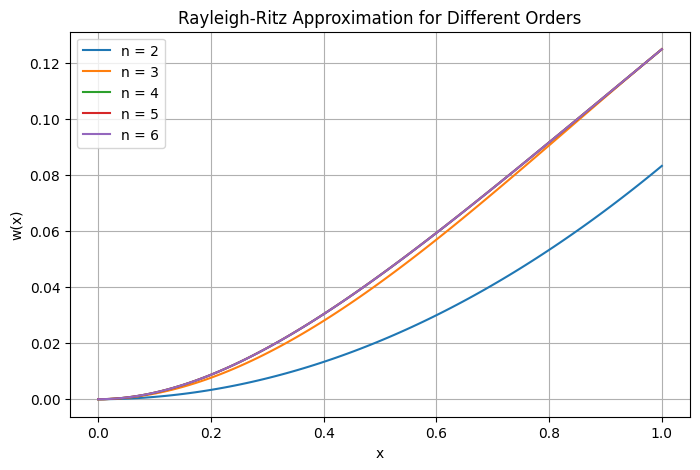

In [ ]:
# Rayleigh-Ritz for a Cantilever Beam
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def rayleigh_ritz(n):
    x, I, E, q, L = sp.symbols('x I E q L')

    # Functions
    E_x = E
    q_x = q
    I_x = I

    # Generating the Polynomial
    coefficients = [sp.Symbol(f'a{i+2}') for i in range(n-1)]
    w_x = sum(coefficients[i] * x**(i+2) for i in range(len(coefficients)))

    # Finding Strain
    strain = sp.diff(sp.diff(w_x, x), x)
    # Finding Total Energy
    pie = 0.5 * sp.integrate(I_x * E_x * strain**2, (x, 0, L)) - sp.integrate(q_x * w_x, (x, 0, L))

    # Differentiating with respect to each coefficient
    equations = [sp.diff(pie, coeff) for coeff in coefficients]
    # Solving the system of equations for coefficients
    solutions = sp.solve(equations, coefficients)

    # Final Equation
    w_x_final = w_x.subs(solutions)
    print(f"Equation for {n} order: ")
    print(w_x_final)

    # Plotting the curve
    w_x_func = sp.lambdify(x, w_x_final.subs({I: 1, q: 1, E: 1, L: 1}), 'numpy')
    x_val = np.linspace(0, 1, 100)
    w_x_plot = w_x_func(x_val)
    plt.plot(x_val, w_x_plot, label = f"n = {n}")

# Run the function for different polynomial orders
orders = [2, 3, 4, 5, 6]
plt.figure(figsize=(8, 5))

for order in orders:
    rayleigh_ritz(order)

# Customize the plot
plt.xlabel("x")
plt.ylabel("w(x)")
plt.title("Rayleigh-Ritz Approximation for Different Orders")
plt.legend()
plt.grid()
plt.show()